In [1]:
!pip install lightly

# ============================
# Imports & Device & Seed
# ============================
import os, shutil, random
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

from lightly.loss import NTXentLoss

# reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
# Cell 2
# ============================
# Dataset Split (Raw + Raw Data only)
# ============================
root_dir = "/kaggle/input/fish-classification-dataset/Fish Data/Fish Data"
working_dir = "/kaggle/working/fish_dataset_split_simclr"

train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15
splits = ["train", "val", "test"]

os.makedirs(working_dir, exist_ok=True)
for s in splits:
    os.makedirs(os.path.join(working_dir, s), exist_ok=True)

# Only split if empty
needs_split = any(len(os.listdir(os.path.join(working_dir, s))) == 0 for s in splits)

if needs_split:
    for cls in os.listdir(root_dir):
        class_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(class_dir):
            continue
        raw_folders = ["Raw", "Raw Data"]
        images = []
        # gather files only (common image extensions)
        exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
        for rf in raw_folders:
            path = os.path.join(class_dir, rf)
            if os.path.exists(path):
                for p in glob(os.path.join(path, "*")):
                    if os.path.isfile(p) and os.path.splitext(p)[1].lower() in exts:
                        images.append(p)
        if len(images) == 0:
            continue

        random.shuffle(images)
        n = len(images)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        n_test = n - n_train - n_val

        assigns = {
            "train": images[:n_train],
            "val": images[n_train:n_train + n_val],
            "test": images[n_train + n_val:]
        }

        for s in splits:
            dest_dir = os.path.join(working_dir, s, cls)
            os.makedirs(dest_dir, exist_ok=True)
            for p in assigns[s]:
                try:
                    shutil.copy(p, dest_dir)
                except Exception as e:
                    # ignore copy errors but print for debugging
                    print(f"Warning: failed to copy {p} -> {dest_dir}: {e}")
    print("✅ Dataset split created in:", working_dir)
else:
    print("ℹ️ Using existing split in:", working_dir)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Cell 3
# ============================
# Pretraining Dataset + Augmentations
# ============================
# Add ImageNet normalization (recommended). If you're training from scratch,
# still helpful to normalize. Adjust mean/std if you want dataset-specific.
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.8, 0.8, 0.8, 0.2),
    transforms.RandomGrayscale(p=0.2),
    # torchvision.transforms.GaussianBlur exists in newer torchvision; kernel_size must be odd/int or tuple
    transforms.GaussianBlur(kernel_size=(3, 3)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# Wrapper dataset for SimCLR (two views per image)
class SimCLRDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # ImageFolder stores (path, class_index) in samples
        path, label = self.dataset.samples[idx]
        img = self.dataset.loader(path)
        x1 = self.transform(img)
        x2 = self.transform(img)
        # return two augmented views (labels not necessary for contrastive pretraining)
        return x1, x2

base_train_dataset = datasets.ImageFolder(os.path.join(working_dir, "train"))
train_dataset = SimCLRDataset(base_train_dataset, simclr_transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True, num_workers=4, pin_memory=True)


In [3]:
# Cell 4
# ============================
# Backbone + Projection Head + SimCLR Pretraining
# ============================
backbone = models.resnet18(pretrained=False)
# replace final FC with identity to get 512-d features
backbone.fc = nn.Identity()

class SimCLR(nn.Module):
    def __init__(self, backbone, num_ftrs=512, projection_dim=128):
        super().__init__()
        self.backbone = backbone
        # a small MLP projection head
        self.projection = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        h = self.backbone(x)
        z = self.projection(h)
        return z

model = SimCLR(backbone).to(device)

# NT-Xent expects normalized embeddings; we'll normalize immediately before passing to criterion
criterion = NTXentLoss(temperature=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-6)

# Training hyperparams
epochs_pre = 100
print_every = 1

for epoch in range(epochs_pre):
    total_loss = 0.0
    model.train()  # important to set bn/dropout to train mode for pretraining
    for x0, x1 in train_loader:
        x0 = x0.to(device, non_blocking=True)
        x1 = x1.to(device, non_blocking=True)

        z0 = model(x0)
        z1 = model(x1)

        # normalize projection vectors before contrastive loss
        z0 = F.normalize(z0, dim=1)
        z1 = F.normalize(z1, dim=1)

        loss = criterion(z0, z1)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / (len(train_loader) if len(train_loader) > 0 else 1)
    if (epoch + 1) % print_every == 0:
        print(f"Epoch [{epoch+1}/{epochs_pre}], SimCLR Loss: {avg_loss:.4f}")

# Save backbone weights (we save backbone.state_dict to load later for finetuning)
torch.save(backbone.state_dict(), "simclr_backbone.pth")
print("✅ SimCLR pretraining finished and backbone saved!")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [1/100], SimCLR Loss: 4.6784
Epoch [2/100], SimCLR Loss: 4.2925
Epoch [3/100], SimCLR Loss: 3.9890
Epoch [4/100], SimCLR Loss: 3.8698
Epoch [5/100], SimCLR Loss: 3.7592
Epoch [6/100], SimCLR Loss: 3.6886
Epoch [7/100], SimCLR Loss: 3.6468
Epoch [8/100], SimCLR Loss: 3.6031
Epoch [9/100], SimCLR Loss: 3.5732
Epoch [10/100], SimCLR Loss: 3.5509
Epoch [11/100], SimCLR Loss: 3.5253
Epoch [12/100], SimCLR Loss: 3.5056
Epoch [13/100], SimCLR Loss: 3.4815
Epoch [14/100], SimCLR Loss: 3.4725
Epoch [15/100], SimCLR Loss: 3.4490
Epoch [16/100], SimCLR Loss: 3.4330
Epoch [17/100], SimCLR Loss: 3.4250
Epoch [18/100], SimCLR Loss: 3.4094
Epoch [19/100], SimCLR Loss: 3.4000
Epoch [20/100], SimCLR Loss: 3.3851
Epoch [21/100], SimCLR Loss: 3.3729
Epoch [22/100], SimCLR Loss: 3.3700
Epoch [23/100], SimCLR Loss: 3.3535
Epoch [24/100], SimCLR Loss: 3.3425
Epoch [25/100], SimCLR Loss: 3.3400
Epoch [26/100], SimCLR Loss: 3.3265
Epoch [27/100], SimCLR Loss: 3.3218
Epoch [28/100], SimCLR Loss: 3.3159
E

In [4]:
# Cell 5
# ============================
# Fine-tuning Dataset + DataLoaders
# ============================
# For finetuning use deterministic transforms and same normalization
finetune_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset_ft = datasets.ImageFolder(os.path.join(working_dir, "train"), transform=finetune_transform)
val_dataset_ft   = datasets.ImageFolder(os.path.join(working_dir, "val"),   transform=finetune_transform)
test_dataset_ft  = datasets.ImageFolder(os.path.join(working_dir, "test"),  transform=finetune_transform)

train_loader_ft = DataLoader(train_dataset_ft, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader_ft   = DataLoader(val_dataset_ft, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader_ft  = DataLoader(test_dataset_ft, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)


In [5]:
# Cell 6
# ============================
# Fine-tuning Model Setup & Training
# ============================
# Reload pretrained backbone
backbone.load_state_dict(torch.load("simclr_backbone.pth", map_location=device))
backbone = backbone.to(device)

# Freeze most backbone layers, unfreeze last two layers (layer3, layer4)
for name, param in backbone.named_parameters():
    param.requires_grad = False
    if "layer3" in name or "layer4" in name:
        param.requires_grad = True

# Make sure BatchNorm layers in unfrozen layers are in train mode during finetuning
# We'll call backbone.train() in the training loop below.

num_classes = len(train_dataset_ft.classes)
classifier = nn.Linear(512, num_classes).to(device)

criterion_cls = nn.CrossEntropyLoss()
optimizer_cls = torch.optim.Adam(
    list(classifier.parameters()) +
    [p for p in backbone.parameters() if p.requires_grad],
    lr=1e-4, weight_decay=1e-6
)
epochs_cls = 50

for epoch in range(epochs_cls):
    # Training
    backbone.train()   # very important so BatchNorm updates for unfrozen layers
    classifier.train()
    total_loss = 0.0
    total_correct = 0

    for images, labels in train_loader_ft:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        features = backbone(images)
        outputs = classifier(features)
        loss = criterion_cls(outputs, labels)

        optimizer_cls.zero_grad()
        loss.backward()
        optimizer_cls.step()

        total_loss += loss.item()
        total_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = total_correct / len(train_dataset_ft) if len(train_dataset_ft) > 0 else 0.0
    avg_loss = total_loss / (len(train_loader_ft) if len(train_loader_ft) > 0 else 1.0)

    # Validation
    backbone.eval()
    classifier.eval()
    total_correct = 0
    with torch.no_grad():
        for images, labels in val_loader_ft:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            features = backbone(images)
            outputs = classifier(features)
            total_correct += (outputs.argmax(1) == labels).sum().item()
    val_acc = total_correct / len(val_dataset_ft) if len(val_dataset_ft) > 0 else 0.0

    print(f"Epoch [{epoch+1}/{epochs_cls}], Loss: {avg_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")


Epoch [1/50], Loss: 1.3963, Train Acc: 0.6599, Val Acc: 0.8946
Epoch [2/50], Loss: 0.3363, Train Acc: 0.9349, Val Acc: 0.9631
Epoch [3/50], Loss: 0.1342, Train Acc: 0.9798, Val Acc: 0.9812
Epoch [4/50], Loss: 0.0651, Train Acc: 0.9922, Val Acc: 0.9871
Epoch [5/50], Loss: 0.0354, Train Acc: 0.9967, Val Acc: 0.9896
Epoch [6/50], Loss: 0.0223, Train Acc: 0.9979, Val Acc: 0.9921
Epoch [7/50], Loss: 0.0127, Train Acc: 0.9997, Val Acc: 0.9921
Epoch [8/50], Loss: 0.0090, Train Acc: 0.9996, Val Acc: 0.9928
Epoch [9/50], Loss: 0.0061, Train Acc: 0.9999, Val Acc: 0.9921
Epoch [10/50], Loss: 0.0062, Train Acc: 0.9996, Val Acc: 0.9911
Epoch [11/50], Loss: 0.0036, Train Acc: 1.0000, Val Acc: 0.9921
Epoch [12/50], Loss: 0.0037, Train Acc: 0.9997, Val Acc: 0.9921
Epoch [13/50], Loss: 0.0035, Train Acc: 0.9997, Val Acc: 0.9928
Epoch [14/50], Loss: 0.0070, Train Acc: 0.9987, Val Acc: 0.9923
Epoch [15/50], Loss: 0.0023, Train Acc: 0.9998, Val Acc: 0.9916
Epoch [16/50], Loss: 0.0013, Train Acc: 1.0000, V

✅ Test Accuracy: 0.9968


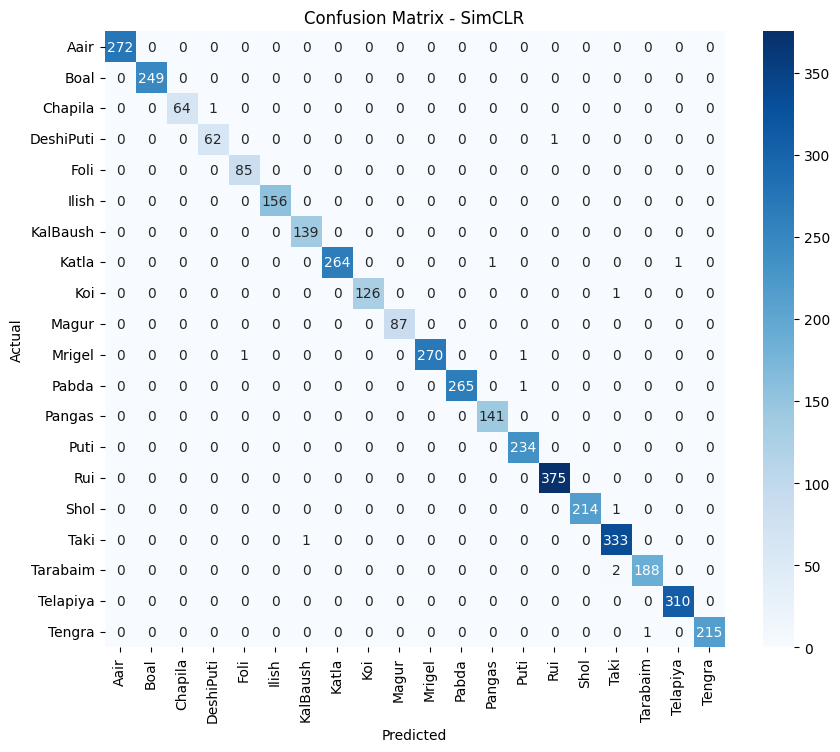

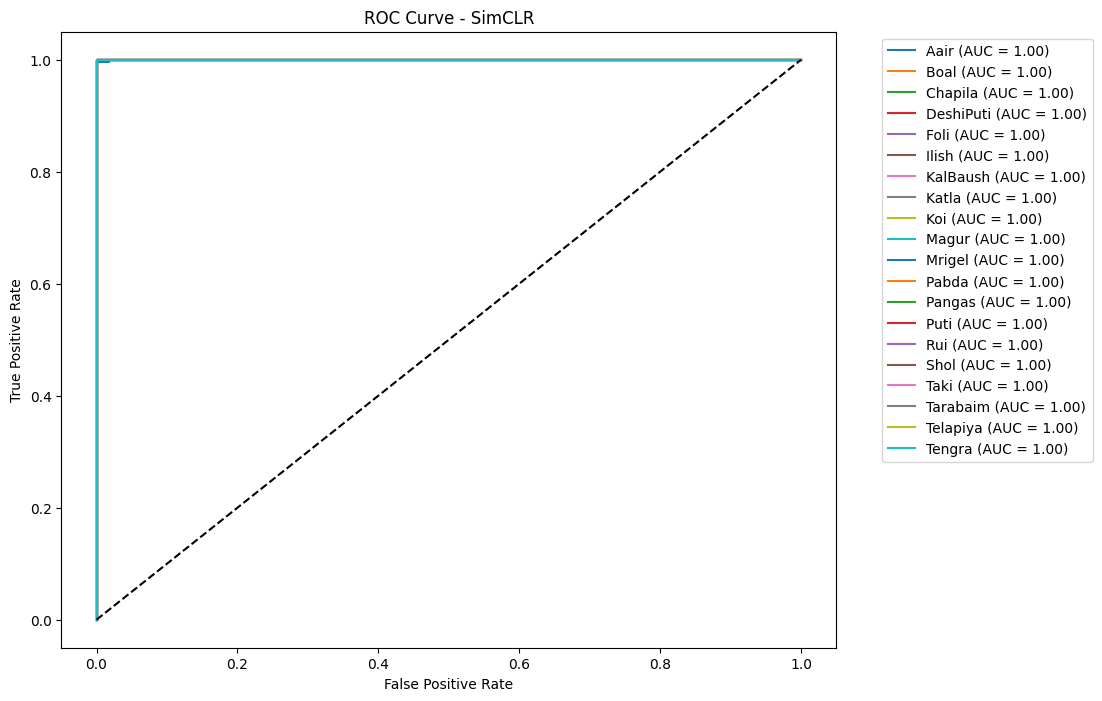

✅ Macro ROC-AUC: 1.0000


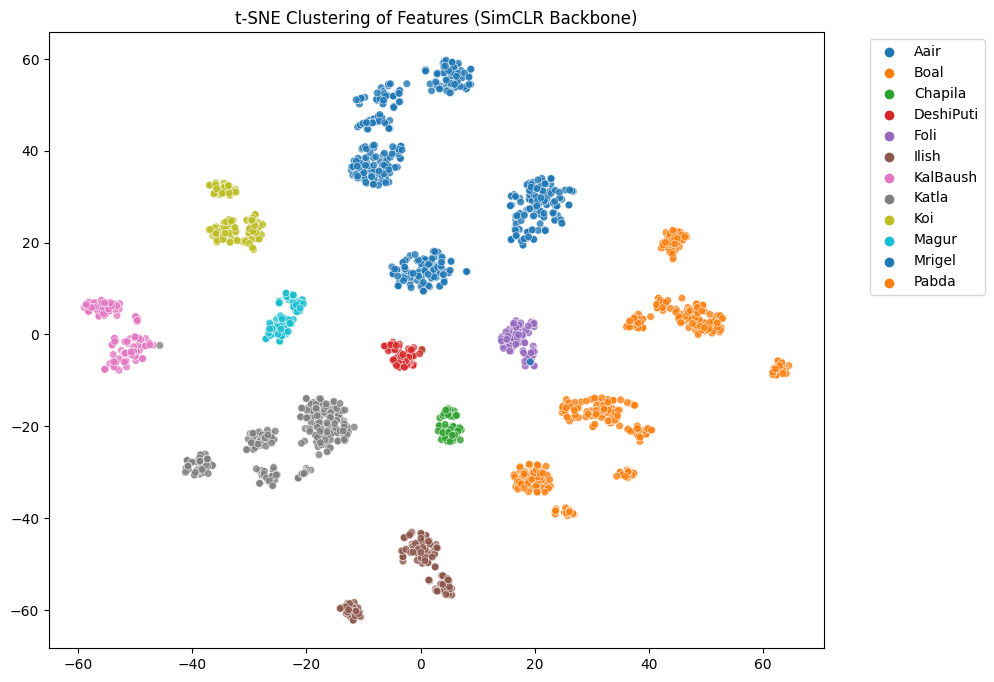

In [6]:
# Cell 7
# ============================
# Test Evaluation, Metrics, t-SNE Visualization
# ============================
backbone.eval()
classifier.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader_ft:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        features = backbone(images)
        outputs = classifier(features)

        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Test Accuracy
test_acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean().item()
print(f"✅ Test Accuracy: {test_acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset_ft.classes, yticklabels=train_dataset_ft.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SimCLR")
plt.show()

# ROC-AUC Curve (One-vs-Rest)
num_classes = len(train_dataset_ft.classes)
y_true_bin = label_binarize(all_labels, classes=list(range(num_classes)))
y_probs = np.array(all_probs)

plt.figure(figsize=(10, 8))
for i in range(num_classes):
    try:
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{train_dataset_ft.classes[i]} (AUC = {roc_auc:.2f})")
    except Exception as e:
        print(f"Warning: could not compute ROC for class {i}: {e}")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SimCLR")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Macro ROC-AUC Score (if possible)
try:
    macro_auc = roc_auc_score(y_true_bin, y_probs, average="macro")
    print(f"✅ Macro ROC-AUC: {macro_auc:.4f}")
except Exception as e:
    print(f"Warning: could not compute macro AUC: {e}")

# ============================
# t-SNE Visualization
# ============================
def plot_tsne(backbone, dataloader, class_names, n_samples=2000):
    backbone.eval()
    features, labels = [], []

    with torch.no_grad():
        for imgs, lbls in dataloader:
            imgs = imgs.to(device)
            feats = backbone(imgs)
            features.append(feats.cpu().numpy())
            labels.append(lbls.numpy())
            if sum(len(l) for l in labels) >= n_samples:
                break

    features = np.concatenate(features, axis=0)[:n_samples]
    labels = np.concatenate(labels, axis=0)[:n_samples]

    # Optional PCA for speed
    from sklearn.decomposition import PCA
    pca = PCA(n_components=50, random_state=42)
    features_pca = pca.fit_transform(features)

    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    embeddings = tsne.fit_transform(features_pca)

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=embeddings[:, 0], y=embeddings[:, 1],
        hue=[class_names[l] for l in labels],
        palette="tab10", s=30, alpha=0.8
    )
    plt.title("t-SNE Clustering of Features (SimCLR Backbone)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

# Example usage
plot_tsne(backbone, test_loader_ft, train_dataset_ft.classes, n_samples=2000)
